In [8]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/PHL_dataset.csv')

print(df.head())
df.info()

                  P_NAME   P_DETECTION P_DISCOVERY_FACILITY  P_YEAR  \
0  OGLE-2016-BLG-1227L b  Microlensing                 OGLE    2020   
1           Kepler-276 c       Transit               Kepler    2013   
2           Kepler-829 b       Transit               Kepler    2016   
3               K2-283 b       Transit                   K2    2018   
4           Kepler-477 b       Transit               Kepler    2016   

     P_UPDATE  P_MASS  P_MASS_ERROR_MIN  P_MASS_ERROR_MAX  P_MASS_LIMIT  \
0  2020-04-02  250.00            -120.0             413.0             0   
1  2018-09-25   16.60              -3.6               4.4             0   
2  2019-04-16    5.10               NaN               NaN             0   
3  2019-09-05   12.20               NaN               NaN             0   
4  2019-04-16    4.94               NaN               NaN             0   

      P_MASS_ORIGIN  ...  S_ABIO_ZONE  S_TIDAL_LOCK  P_HABZONE_OPT  \
0              Mass  ...          NaN      0.214133 

In [9]:
df.shape

(5599, 118)

In [10]:
df.columns

Index(['P_NAME', 'P_DETECTION', 'P_DISCOVERY_FACILITY', 'P_YEAR', 'P_UPDATE',
       'P_MASS', 'P_MASS_ERROR_MIN', 'P_MASS_ERROR_MAX', 'P_MASS_LIMIT',
       'P_MASS_ORIGIN',
       ...
       'S_ABIO_ZONE', 'S_TIDAL_LOCK', 'P_HABZONE_OPT', 'P_HABZONE_CON',
       'P_TYPE_TEMP', 'P_HABITABLE', 'P_ESI', 'S_CONSTELLATION',
       'S_CONSTELLATION_ABR', 'S_CONSTELLATION_ENG'],
      dtype='object', length=118)

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
cols_to_keep = [

    'P_HABITABLE',
    'P_ESI',
    'P_RADIUS',
    'P_MASS',
    'P_GRAVITY',
    'P_ESCAPE',
    'P_PERIOD',
    'P_SEMI_MAJOR_AXIS',
    'P_ECCENTRICITY',
    'P_INCLINATION',
    'P_TEMP_EQUIL',
    'P_TEMP_SURF',
    'P_TYPE_TEMP',

    'S_MASS',
    'S_RADIUS',
    'S_TEMPERATURE',
    'S_METALLICITY',
    'S_AGE',
    'S_MAG',
    'S_DISTANCE',
    'S_TYPE'
]


df = df[[col for col in cols_to_keep if col in df.columns]]

In [13]:
df.shape

(5599, 21)

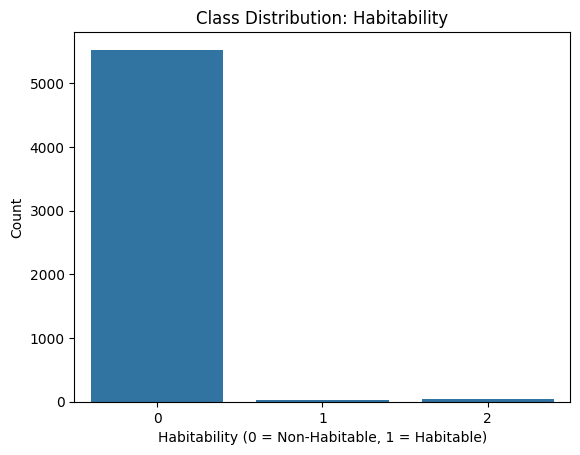

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='P_HABITABLE', data=df)
plt.title("Class Distribution: Habitability")
plt.xlabel("Habitability (0 = Non-Habitable, 1 = Habitable)")
plt.ylabel("Count")
plt.show()

In [15]:
# Binarize the 'P_HABITABLE' column based on the logic: if 0, then 0, otherwise 1
df['P_HABITABLE'] = df['P_HABITABLE'].apply(lambda x: 0 if x == 0 else 1)

In [16]:
df['P_HABITABLE'].value_counts()

,count
P_HABITABLE,
0,5529
1,70


Identify missing values

In [17]:
missing_values = df.isnull().sum()
missing_percentage = 100 * df.isnull().sum() / len(df)

missing_df = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percentage})
missing_df = missing_df[missing_df['Missing Values'] > 0].sort_values(by='Percentage', ascending=False)

print('Columns with Missing Values :')
print(missing_df.head(30))

Columns with Missing Values :
                   Missing Values  Percentage
S_TYPE                       3578   63.904269
P_TEMP_SURF                  3158   56.402929
P_INCLINATION                1311   23.414896
S_AGE                        1207   21.557421
P_ECCENTRICITY                777   13.877478
S_METALLICITY                 433    7.733524
P_PERIOD                      249    4.447223
P_ESI                         241    4.304340
P_TYPE_TEMP                   234    4.179318
P_TEMP_EQUIL                  234    4.179318
S_RADIUS                      232    4.143597
S_MAG                         219    3.911413
S_TEMPERATURE                 219    3.911413
S_DISTANCE                     21    0.375067
P_RADIUS                        7    0.125022
P_MASS                          7    0.125022
P_GRAVITY                       7    0.125022
P_ESCAPE                        7    0.125022
P_SEMI_MAJOR_AXIS               4    0.071441
S_MASS                          4    0.071441


In [18]:
df.head()

,P_HABITABLE,P_ESI,P_RADIUS,P_MASS,P_GRAVITY,P_ESCAPE,P_PERIOD,P_SEMI_MAJOR_AXIS,P_ECCENTRICITY,P_INCLINATION,...,P_TEMP_SURF,P_TYPE_TEMP,S_MASS,S_RADIUS,S_TEMPERATURE,S_METALLICITY,S_AGE,S_MAG,S_DISTANCE,S_TYPE
0,0,NaN,13.90,250.00,1.293929,4.240945,NaN,3.4000,NaN,NaN,...,NaN,NaN,0.10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,0.272032,2.90,16.60,1.973841,2.392517,31.884000,0.1994,0.0,86.92,...,NaN,Hot,1.10,1.03,5779.0,0.02,0.40,15.481,1144.860,NaN
2,0,0.254763,2.11,5.10,1.145527,1.554690,6.883376,0.0678,0.0,89.82,...,1130.60440,Hot,0.98,0.97,5698.0,0.03,4.68,14.973,1073.760,NaN
3,0,0.193906,3.52,12.20,0.984633,1.861695,1.921036,0.0291,NaN,NaN,...,NaN,Hot,0.89,0.82,5060.0,0.28,NaN,14.364,402.915,NaN
4,0,0.276721,2.07,4.94,1.152886,1.544822,11.119907,0.0911,0.0,87.75,...,769.42507,Hot,0.87,0.79,5240.0,-0.04,2.09,13.835,367.000,NaN


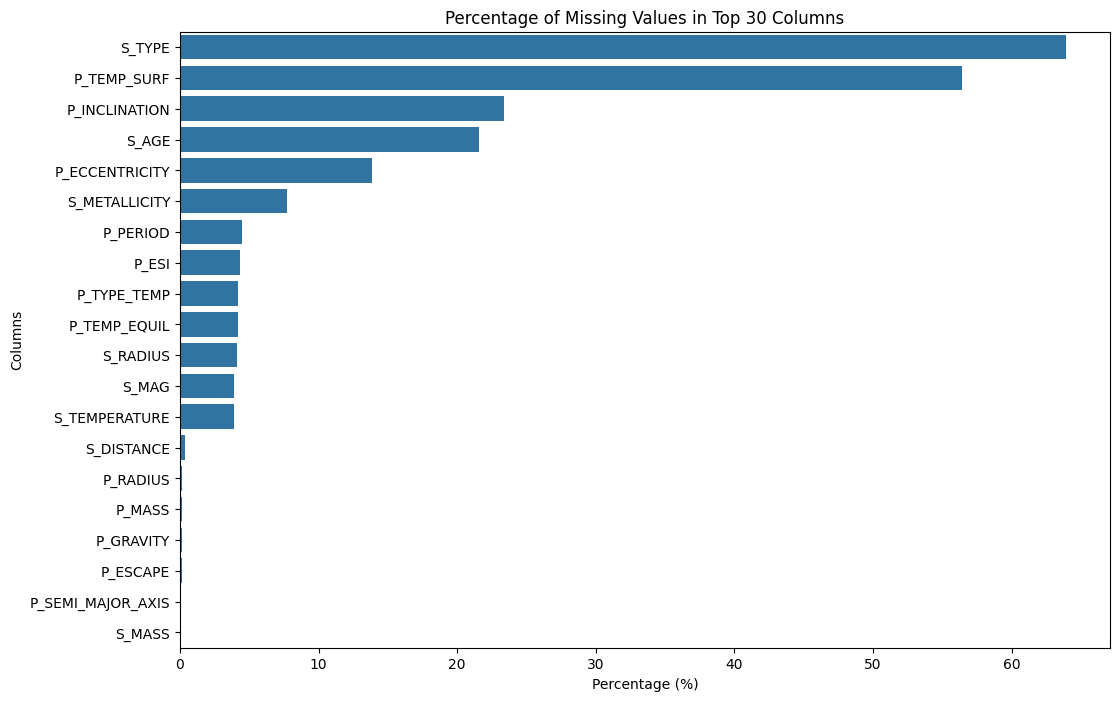

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.barplot(x=missing_df['Percentage'].head(30), y=missing_df.head(30).index)
plt.title('Percentage of Missing Values in Top 30 Columns')
plt.xlabel('Percentage (%)')
plt.ylabel('Columns')
plt.show()

In [20]:
df.isnull().sum()

,0
P_HABITABLE,0
P_ESI,241
P_RADIUS,7
P_MASS,7
P_GRAVITY,7
P_ESCAPE,7
P_PERIOD,249
P_SEMI_MAJOR_AXIS,4
P_ECCENTRICITY,777
P_INCLINATION,1311


In [21]:
df = df[df.isnull().mean(axis=1) < 0.5]


In [22]:
df.shape

(5391, 21)

In [23]:
numerical_cols = df.select_dtypes(include=['number']).columns

# filter out numerical columns with more than 50% missing values
numerical_cols = [col for col in numerical_cols if missing_percentage.get(col, 0) <= 50]

print(f"Number of numerical columns: {len(numerical_cols)}")
print(f"Number of suitable numerical columns (<= 50% missing values): {len(numerical_cols)}")
print("Suitable numerical columns for outlier detection:")
print(numerical_cols)

Number of numerical columns: 18
Number of suitable numerical columns (<= 50% missing values): 18
Suitable numerical columns for outlier detection:
['P_HABITABLE', 'P_ESI', 'P_RADIUS', 'P_MASS', 'P_GRAVITY', 'P_ESCAPE', 'P_PERIOD', 'P_SEMI_MAJOR_AXIS', 'P_ECCENTRICITY', 'P_INCLINATION', 'P_TEMP_EQUIL', 'S_MASS', 'S_RADIUS', 'S_TEMPERATURE', 'S_METALLICITY', 'S_AGE', 'S_MAG', 'S_DISTANCE']


In [24]:
df.describe()

,P_HABITABLE,P_ESI,P_RADIUS,P_MASS,P_GRAVITY,P_ESCAPE,P_PERIOD,P_SEMI_MAJOR_AXIS,P_ECCENTRICITY,P_INCLINATION,P_TEMP_EQUIL,P_TEMP_SURF,S_MASS,S_RADIUS,S_TEMPERATURE,S_METALLICITY,S_AGE,S_MAG,S_DISTANCE
count,5391.000000,5358.000000,5384.000000,5384.000000,5384.000000,5384.000000,5.341000e+03,5391.000000,4821.000000,4287.000000,5365.000000,2441.000000,5388.000000,5366.000000,5375.000000,5166.000000,4390.000000,5372.000000,5375.000000
mean,0.012985,0.257089,5.551767,428.913643,3.912721,3.577060,8.007162e+04,6.449077,0.076423,86.870680,792.985586,971.994023,0.970046,1.545829,5431.707274,0.013706,4.375765,12.616793,520.460696
std,0.113218,0.131622,5.292013,2396.211016,14.162683,4.631820,5.503227e+06,133.123476,0.150536,10.544164,484.434177,487.382871,0.415107,4.198076,1777.230595,0.213459,3.086635,3.045248,518.844800
min,0.000000,0.023896,0.310000,0.020000,0.038086,0.243252,9.070629e-02,0.004400,0.000000,0.370000,1.084914,130.661650,0.010000,0.010000,575.000000,-1.000000,0.001000,0.872000,1.301190
25%,0.000000,0.186192,1.750000,3.940000,1.024105,1.468477,4.463129e+00,0.051900,0.000000,86.900000,456.758880,638.352490,0.810000,0.780000,4943.500000,-0.080000,2.340000,10.830125,107.796000
50%,0.000000,0.268055,2.710000,8.400000,1.165000,1.733053,1.155102e+01,0.097400,0.000000,88.761000,727.306290,908.701120,0.950000,0.960000,5555.000000,0.020000,3.980000,13.460000,388.630000
75%,0.000000,0.301299,11.209000,133.488600,1.522080,3.456230,4.105854e+01,0.237000,0.090000,89.670000,1049.902400,1204.326300,1.100000,1.250000,5902.000000,0.120000,5.392500,15.002250,808.762000
max,1.000000,0.968362,77.342000,89700.000000,387.976070,52.455064,4.020000e+08,7506.000000,0.950000,176.092000,7800.730100,8125.496300,10.940000,109.460000,57000.000000,7.790000,14.900000,24.730000,8500.000000


In [25]:
import pandas as pd

# Apply one-hot encoding to 'P_TYPE_TEMP as it has 3 unique values'
df = pd.get_dummies(df, columns=['P_TYPE_TEMP'], prefix='P_TYPE_TEMP')

print("DataFrame after one-hot encoding 'P_TYPE_TEMP':")
df.head()
df.info()

DataFrame after one-hot encoding 'P_TYPE_TEMP':
<class 'pandas.core.frame.DataFrame'>
Index: 5391 entries, 1 to 5597
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   P_HABITABLE        5391 non-null   int64  
 1   P_ESI              5358 non-null   float64
 2   P_RADIUS           5384 non-null   float64
 3   P_MASS             5384 non-null   float64
 4   P_GRAVITY          5384 non-null   float64
 5   P_ESCAPE           5384 non-null   float64
 6   P_PERIOD           5341 non-null   float64
 7   P_SEMI_MAJOR_AXIS  5391 non-null   float64
 8   P_ECCENTRICITY     4821 non-null   float64
 9   P_INCLINATION      4287 non-null   float64
 10  P_TEMP_EQUIL       5365 non-null   float64
 11  P_TEMP_SURF        2441 non-null   float64
 12  S_MASS             5388 non-null   float64
 13  S_RADIUS           5366 non-null   float64
 14  S_TEMPERATURE      5375 non-null   float64
 15  S_METALLICITY      5166 non-n

In [26]:
outliers_data = {}

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    outliers_data[col] = outliers

print("Outliers calculated for suitable numerical columns.")
print(f"Number of columns with identified outliers: {len([col for col, data in outliers_data.items() if not data.empty])}")

Outliers calculated for suitable numerical columns.
Number of columns with identified outliers: 18


In [27]:
for col, outliers in outliers_data.items():
    print(f"Column '{col}': {len(outliers)} outliers")

Column 'P_HABITABLE': 70 outliers
Column 'P_ESI': 291 outliers
Column 'P_RADIUS': 6 outliers
Column 'P_MASS': 965 outliers
Column 'P_GRAVITY': 1089 outliers
Column 'P_ESCAPE': 744 outliers
Column 'P_PERIOD': 938 outliers
Column 'P_SEMI_MAJOR_AXIS': 876 outliers
Column 'P_ECCENTRICITY': 579 outliers
Column 'P_INCLINATION': 438 outliers
Column 'P_TEMP_EQUIL': 86 outliers
Column 'S_MASS': 395 outliers
Column 'S_RADIUS': 364 outliers
Column 'S_TEMPERATURE': 269 outliers
Column 'S_METALLICITY': 201 outliers
Column 'S_AGE': 308 outliers
Column 'S_MAG': 55 outliers
Column 'S_DISTANCE': 87 outliers


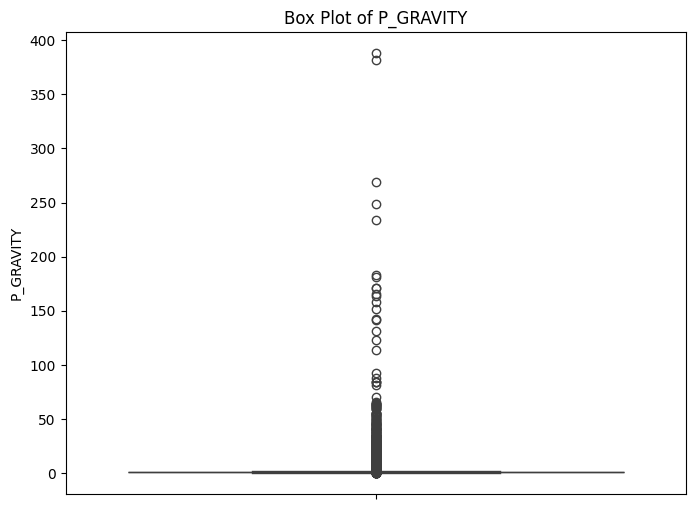

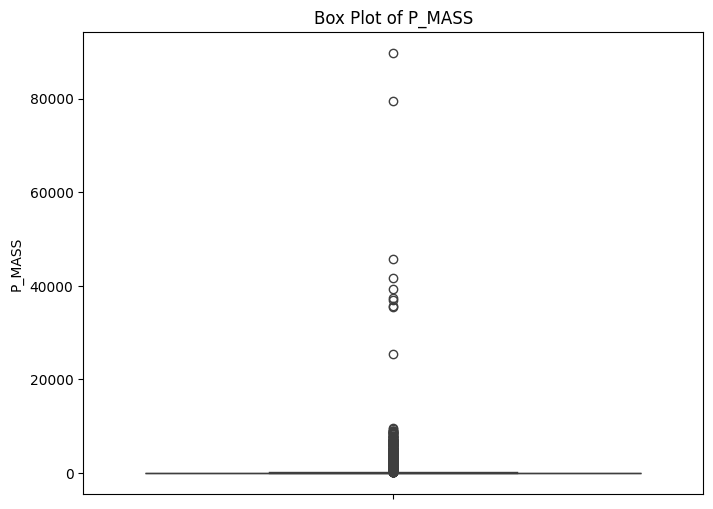

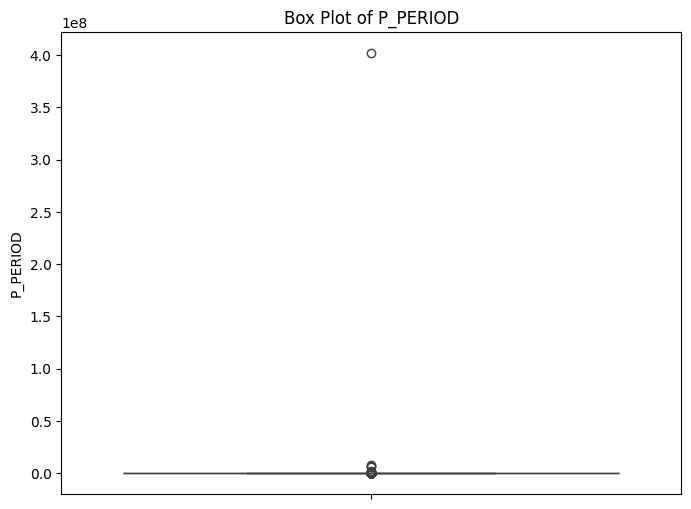

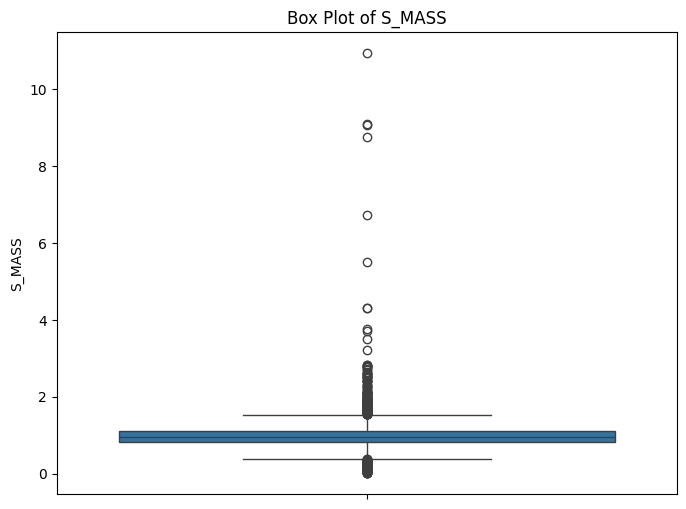

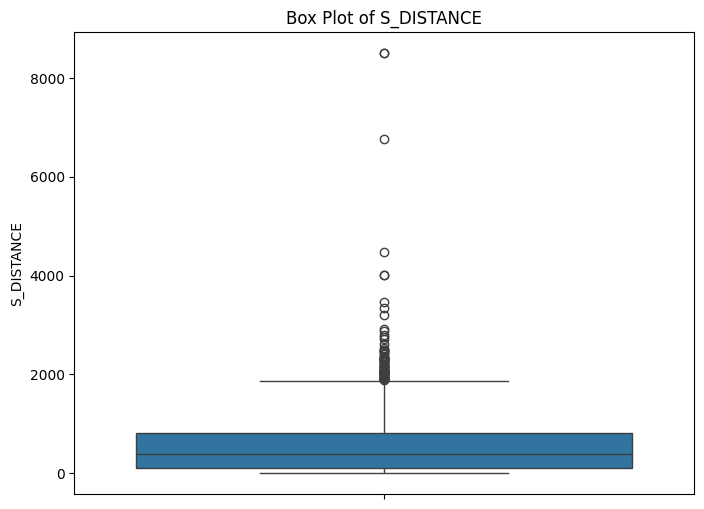

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Based on the previous outlier detection, these columns show significant outliers
key_numerical_cols = [ 'P_GRAVITY', 'P_MASS', 'P_PERIOD', 'S_MASS',  'S_DISTANCE']

for col in key_numerical_cols:
    plt.figure(figsize=(8, 6))
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
    plt.show()


Imputing missing values

In [29]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.drop(['P_HABITABLE', 'P_ESI'], errors='ignore')
cat_cols = df.select_dtypes(include=["object","bool"]).columns

# Numerical: Median Imputation
for col in num_cols:
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value)

# Categorical: Mode Imputation
for col in cat_cols:
    mode_value = df[col].mode()
    if not mode_value.empty:
        df[col] = df[col].fillna(mode_value[0])

print("Remaining missing values:\n")
print(df.isnull().sum())

Remaining missing values:

P_HABITABLE           0
P_ESI                33
P_RADIUS              0
P_MASS                0
P_GRAVITY             0
P_ESCAPE              0
P_PERIOD              0
P_SEMI_MAJOR_AXIS     0
P_ECCENTRICITY        0
P_INCLINATION         0
P_TEMP_EQUIL          0
P_TEMP_SURF           0
S_MASS                0
S_RADIUS              0
S_TEMPERATURE         0
S_METALLICITY         0
S_AGE                 0
S_MAG                 0
S_DISTANCE            0
S_TYPE                0
P_TYPE_TEMP_Cold      0
P_TYPE_TEMP_Hot       0
P_TYPE_TEMP_Warm      0
dtype: int64


In [30]:
# IQR capping
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = df[col].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)



In [31]:
# # Log transform skewed features
skewed_cols = df[num_cols].skew().abs()
skewed_cols = skewed_cols[skewed_cols > 1].index

df[skewed_cols] = np.log1p(df[skewed_cols])

In [32]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Separate features and targets
target_cols = ["P_HABITABLE", "P_ESI"]
feature_cols = [col for col in df.columns if col not in target_cols ]

# Select numerical features only
num_cols = df[feature_cols].select_dtypes(include=["int64", "float64"]).columns

# Apply Standard Scaling
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])



In [33]:
df_numeric = df.select_dtypes(include=[np.number]).drop(columns=['P_TEMP_SURF'])
df_numeric.corr()

,P_HABITABLE,P_ESI,P_RADIUS,P_MASS,P_GRAVITY,P_ESCAPE,P_PERIOD,P_SEMI_MAJOR_AXIS,P_ECCENTRICITY,P_INCLINATION,P_TEMP_EQUIL,S_MASS,S_RADIUS,S_TEMPERATURE,S_METALLICITY,S_AGE,S_MAG,S_DISTANCE
P_HABITABLE,1.000000,0.421052,-0.093282,-0.088304,-0.027512,-0.075670,0.085917,0.034253,0.035483,0.071500,-0.143076,-0.193807,-0.169183,-0.206329,-0.080720,-0.004983,0.034558,-0.087644
P_ESI,0.421052,1.000000,-0.603099,-0.576156,-0.198522,-0.513049,0.220275,0.083270,-0.129092,0.267188,-0.406148,-0.459397,-0.449309,-0.365147,-0.206781,0.036021,0.246948,-0.029838
P_RADIUS,-0.093282,-0.603099,1.000000,0.962422,0.380719,0.876995,0.313508,0.465580,0.477090,-0.100868,-0.088185,0.398542,0.456806,0.178218,0.213947,-0.014245,-0.498064,-0.239540
P_MASS,-0.088304,-0.576156,0.962422,1.000000,0.570958,0.967122,0.320795,0.479230,0.499087,-0.097909,-0.109017,0.385656,0.443612,0.150904,0.213366,-0.024482,-0.508357,-0.261942
P_GRAVITY,-0.027512,-0.198522,0.380719,0.570958,1.000000,0.747889,0.183641,0.320048,0.336561,-0.092574,-0.104774,0.202706,0.229038,0.010298,0.072808,-0.066554,-0.348861,-0.238971
P_ESCAPE,-0.075670,-0.513049,0.876995,0.967122,0.747889,1.000000,0.321305,0.487789,0.494830,-0.098388,-0.128886,0.368744,0.422563,0.124020,0.187144,-0.047466,-0.504775,-0.272774
P_PERIOD,0.085917,0.220275,0.313508,0.320795,0.183641,0.321305,1.000000,0.914573,0.380628,0.317602,-0.773947,0.166895,0.217050,0.036396,-0.045620,0.004520,-0.363830,-0.094034
P_SEMI_MAJOR_AXIS,0.034253,0.083270,0.465580,0.479230,0.320048,0.487789,0.914573,1.000000,0.443808,0.221325,-0.681203,0.241281,0.300522,0.059922,-0.000606,-0.023308,-0.463458,-0.160523
P_ECCENTRICITY,0.035483,-0.129092,0.477090,0.499087,0.336561,0.494830,0.380628,0.443808,1.000000,0.021057,-0.297241,0.111026,0.186515,-0.082415,0.073490,0.083787,-0.595423,-0.436646
P_INCLINATION,0.071500,0.267188,-0.100868,-0.097909,-0.092574,-0.098388,0.317602,0.221325,0.021057,1.000000,-0.369726,-0.125881,-0.130069,-0.131168,-0.085062,-0.021462,0.039915,-0.015699


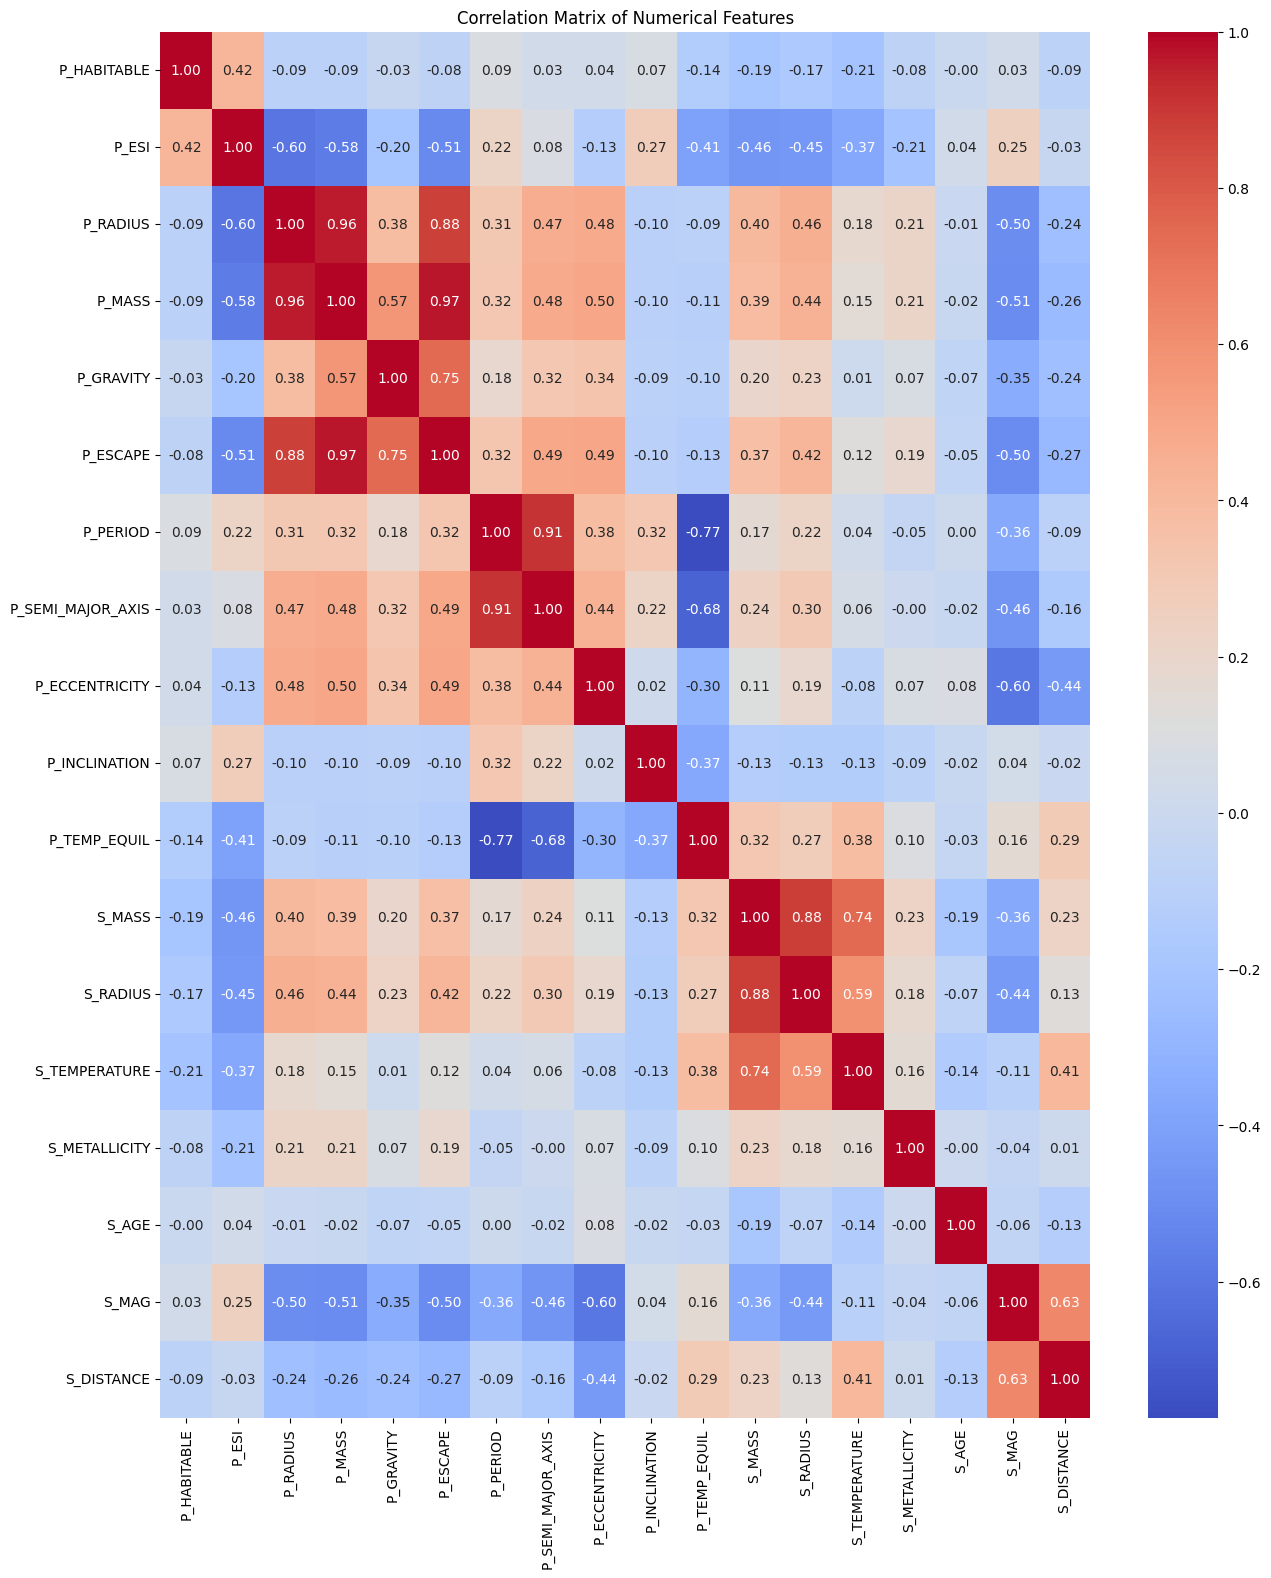

In [34]:
plt.figure(figsize=(15, 18))
sns.heatmap(df_numeric.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

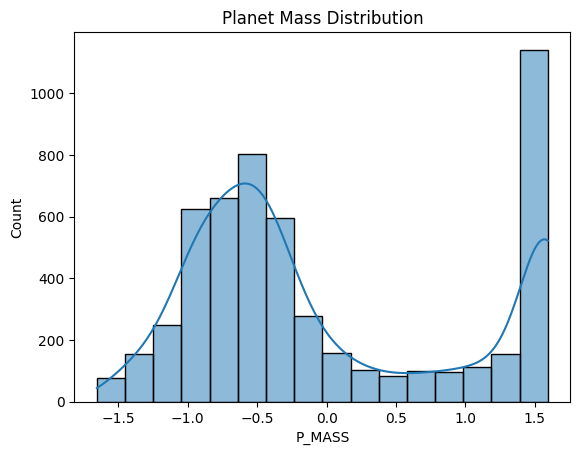

In [35]:
sns.histplot(df['P_MASS'], kde=True)
plt.title("Planet Mass Distribution")
plt.show()


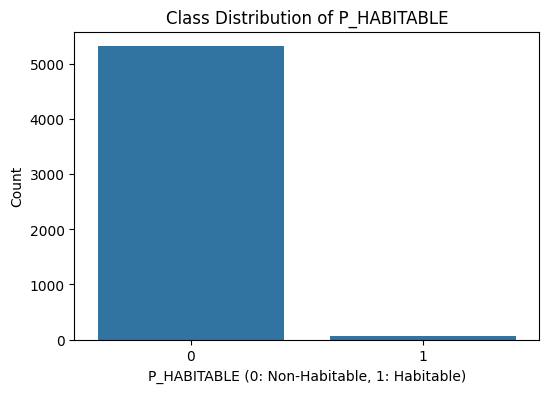

In [43]:
y = df['P_HABITABLE']
plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title('Class Distribution of P_HABITABLE')
plt.xlabel('P_HABITABLE (0: Non-Habitable, 1: Habitable)')
plt.ylabel('Count')
plt.show()

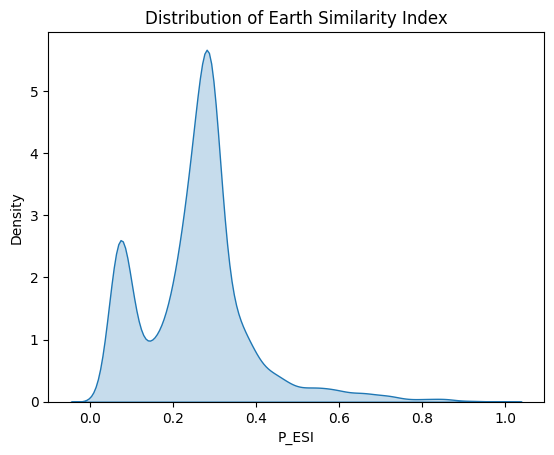

In [37]:
sns.kdeplot(df["P_ESI"], fill=True)
plt.title("Distribution of Earth Similarity Index")
plt.show()


In [38]:
y = df['P_HABITABLE']
X = df.drop(columns=['P_HABITABLE', 'P_ESI', 'S_TYPE'])

In [39]:
from sklearn.decomposition import PCA
import pandas as pd

X_numeric = X.select_dtypes(include=['number'])
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_numeric)

print("Explained variance ratio of PCA components:", pca.explained_variance_ratio_)


Explained variance ratio of PCA components: [0.33811197 0.19230539]


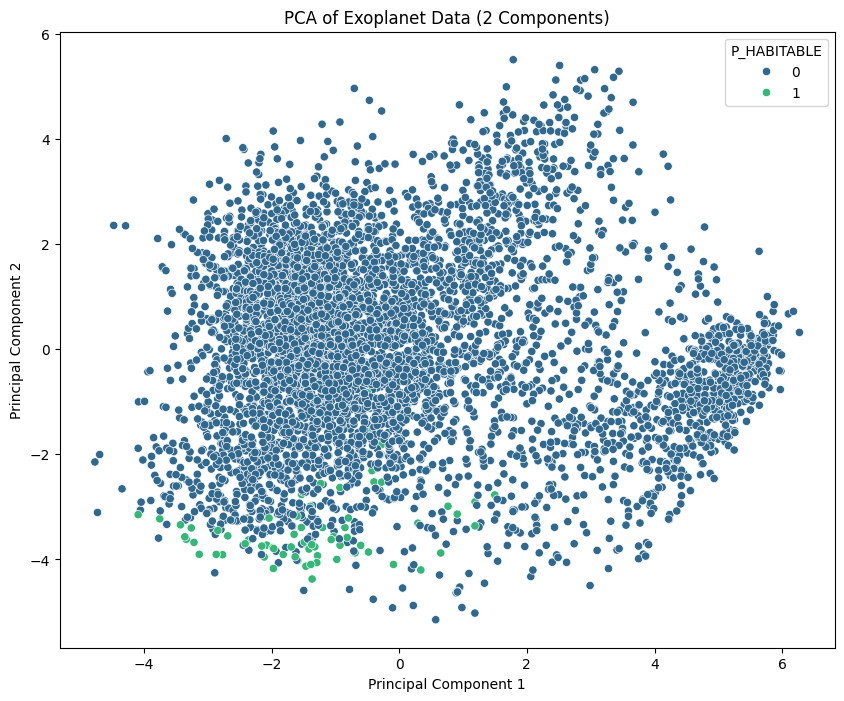

In [40]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='viridis')
plt.title('PCA of Exoplanet Data (2 Components)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='P_HABITABLE')
plt.show()

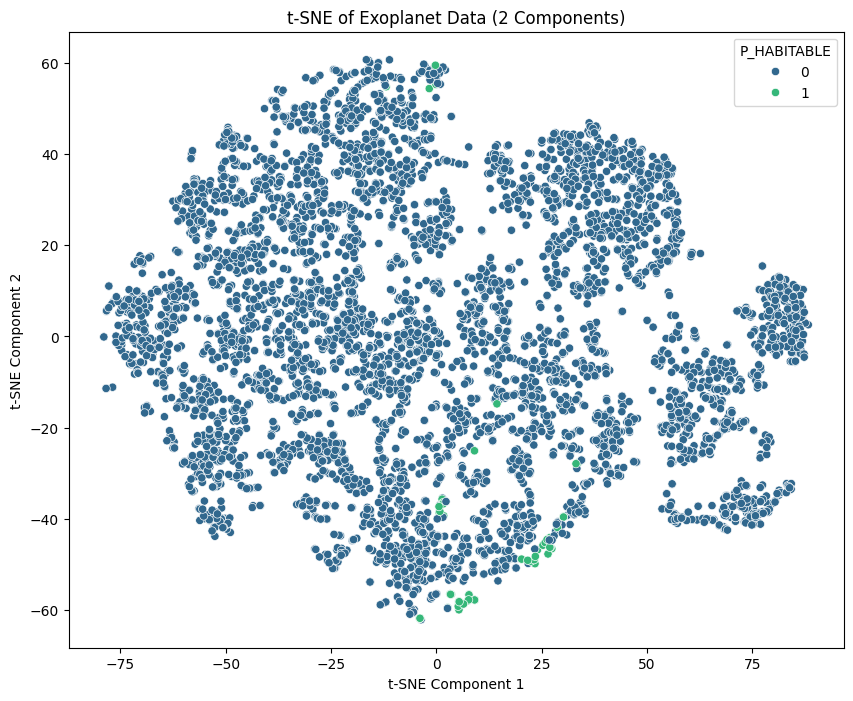

In [41]:
from sklearn.manifold import TSNE

# t-SNE with 2 components
tsne = TSNE(n_components=2, random_state=42)

X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y, palette='viridis')
plt.title('t-SNE of Exoplanet Data (2 Components)')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend(title='P_HABITABLE')
plt.show()